# PyBaMM RPT 结果可视化

本 notebook 读取 `outputs/<case>/rpt_metrics.csv` 与 `summary.json`，重点展示 `SOH / LLI / LAM / 内阻` 随等效循环数的变化。

支持以下环境变量，以便 `Reproduce_Li2024` 或 `PyBaMM-ESE-Public` 被移出原仓库位置后继续使用：

- `PYBAMM_ROOT` 或 `PYBAMM_REPO_ROOT`：外部 `PyBaMM-ESE-Public` 仓库根目录，或其下的 `pybamm/` 包目录
- `REPRODUCE_LI2024_ROOT`：当前 `Reproduce_Li2024` 根目录
- `REPRODUCE_CASE_NAME`：默认读取的 case 名称
- `REPRODUCE_CASE_DIR`：直接指定输出目录，优先级最高


In [1]:
from pathlib import Path
import json
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt

def _normalise_pybamm_root(path):
    resolved = Path(path).expanduser().resolve()
    if (resolved / 'pybamm' / '__init__.py').is_file():
        return resolved
    if resolved.name == 'pybamm' and (resolved / '__init__.py').is_file():
        return resolved.parent
    raise ValueError(
        f"Invalid pybamm root '{resolved}'. Expected a repository root containing `pybamm/` or the `pybamm/` package directory."
    )

def _find_reproduce_root(start):
    current = start.expanduser().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'configs' / 'cases').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    return None

def _resolve_reproduce_root():
    env_value = os.environ.get('REPRODUCE_LI2024_ROOT')
    if env_value:
        return Path(env_value).expanduser().resolve()
    return _find_reproduce_root(Path.cwd())

def _resolve_pybamm_root(reproduce_root):
    for env_name in ('PYBAMM_ROOT', 'PYBAMM_REPO_ROOT'):
        env_value = os.environ.get(env_name)
        if env_value:
            return _normalise_pybamm_root(env_value), f'env:{env_name}'

    if reproduce_root is not None:
        sibling_root = reproduce_root.parent
        if (sibling_root / 'pybamm' / '__init__.py').is_file():
            return sibling_root, 'default'

    return None, 'not-set'

REPRODUCE_ROOT = _resolve_reproduce_root()
PYBAMM_ROOT, PYBAMM_ROOT_SOURCE = _resolve_pybamm_root(REPRODUCE_ROOT)
if PYBAMM_ROOT is not None and str(PYBAMM_ROOT) not in sys.path:
    sys.path.insert(0, str(PYBAMM_ROOT))

CASE_NAME = os.environ.get('REPRODUCE_CASE_NAME', 'okane2023_full_cycle')
CASE_DIR_ENV = os.environ.get('REPRODUCE_CASE_DIR')
if CASE_DIR_ENV:
    CASE_DIR = Path(CASE_DIR_ENV).expanduser().resolve()
elif REPRODUCE_ROOT is not None:
    CASE_DIR = (REPRODUCE_ROOT / 'outputs' / CASE_NAME).resolve()
else:
    CASE_DIR = Path('..', 'outputs', CASE_NAME).resolve()

print(f'Reproduce root: {REPRODUCE_ROOT}')
print(f'PyBaMM root ({PYBAMM_ROOT_SOURCE}): {PYBAMM_ROOT}')
print(f'Case dir: {CASE_DIR}')

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 120


Reproduce root: /home/yanli/zhongxiansun/AlphaBattery/Reproduce_Li2024
PyBaMM root (default): /home/yanli/zhongxiansun/AlphaBattery
Case dir: /home/yanli/zhongxiansun/AlphaBattery/Reproduce_Li2024/outputs/okane2023_full_cycle


In [2]:
summary = json.loads((CASE_DIR / 'summary.json').read_text(encoding='utf-8'))
rpt_df = pd.read_csv(CASE_DIR / 'rpt_metrics.csv')
summary


{'case_name': 'okane2023_full_cycle',
 'config_path': '/home/yanli/zhongxiansun/AlphaBattery/Reproduce_Li2024/configs/cases/okane2023_full_cycle.json',
 'model_type': 'DFN',
 'parameter_set': 'OKane2023',
 'target_equivalent_cycles': 78.0,
 'rpt_interval_equivalent_cycles': 1.0,
 'equivalent_cycle_definition': 'Equivalent cycle = cumulative discharged capacity during ageing / nominal cell capacity',
 'count_rpt_discharge_in_equivalent_cycles': False,
 'n_experiment_cycles': 175,
 'n_ageing_blocks_completed': 96,
 'n_rpt_checkpoints': 79,
 'output_variables_saved': ['Time [h]',
  'Current [A]',
  'Terminal voltage [V]',
  'Discharge capacity [A.h]',
  'Throughput capacity [A.h]',
  'Loss of capacity to SEI [A.h]',
  'Loss of capacity to SEI on cracks [A.h]',
  'Loss of capacity to lithium plating [A.h]',
  'Negative electrode capacity [A.h]',
  'Positive electrode capacity [A.h]',
  'Total lithium capacity in particles [A.h]',
  'X-averaged negative electrode porosity'],
 'output_variab

In [3]:
rpt_df[['equivalent_cycle', 'rpt_type', 'soh_percent', 'lli_percent', 'lam_ne_percent', 'lam_pe_percent', 'internal_resistance_mohm']].head()


,equivalent_cycle,rpt_type,soh_percent,lli_percent,lam_ne_percent,lam_pe_percent,internal_resistance_mohm
0,0.0,long,100.000000,0.000000,0.000000,0.0,29.318333
1,1.0,long,100.042518,0.044920,0.021579,0.0,29.341245
2,2.0,short,99.989492,0.087023,0.036154,0.0,29.361947
3,3.0,long,99.947974,0.116372,0.052878,0.0,29.378379
4,4.0,short,99.894037,0.157688,0.067417,0.0,29.398647


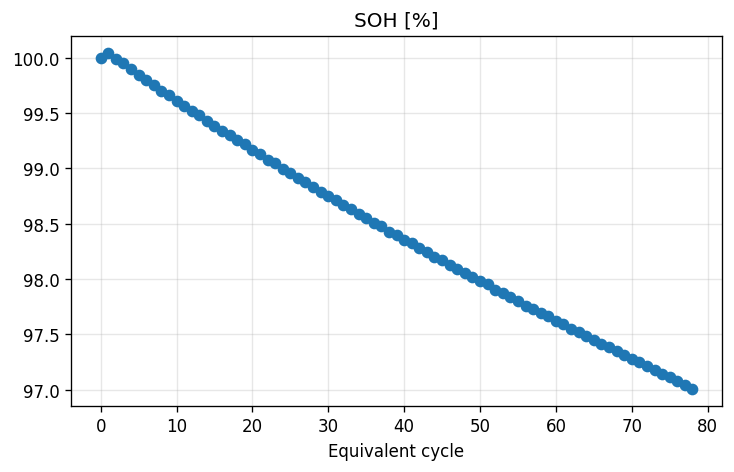

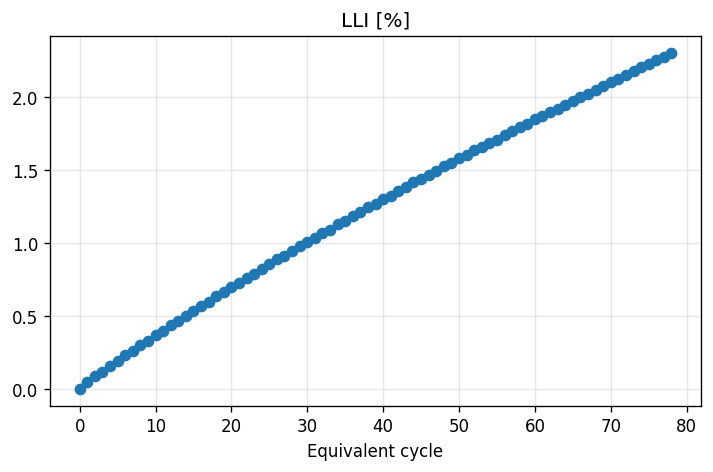

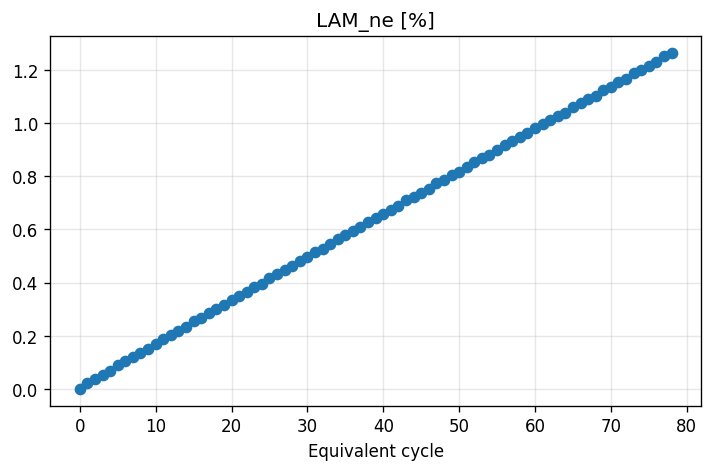

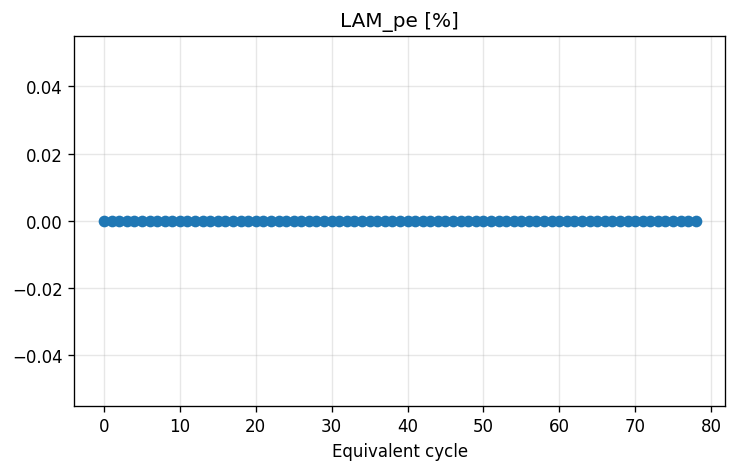

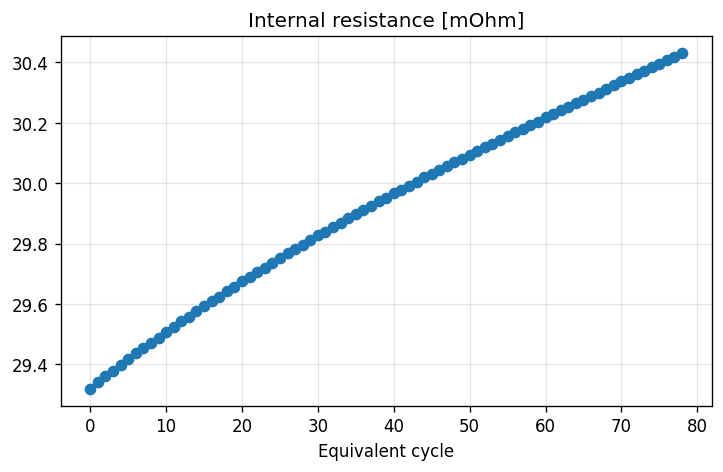

In [4]:
plot_specs = [
    ('soh_percent', 'SOH [%]'),
    ('lli_percent', 'LLI [%]'),
    ('lam_ne_percent', 'LAM_ne [%]'),
    ('lam_pe_percent', 'LAM_pe [%]'),
    ('internal_resistance_mohm', 'Internal resistance [mOhm]'),
]
for column, title in plot_specs:
    if column not in rpt_df.columns:
        continue
    ax = rpt_df.plot(x='equivalent_cycle', y=column, marker='o', legend=False)
    ax.set_title(title)
    ax.set_xlabel('Equivalent cycle')
    ax.grid(True, alpha=0.3)
    plt.show()


In [ ]:
import numpy as pybamm
import matplotlib.pyplot as plt

def graphite_LGM50_delithiation_ocp_OKane2023(sto):
    """
    LG M50 Graphite delithiation open-circuit potential as a function of stochiometry.
    Fitted to unpublished measurements taken by Kieran O'Regan.

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stochiometry

    Returns
    -------
    :class:`pybamm.Symbol`
        Open circuit potential
    """

    u_eq = (
        1.051 * pybamm.exp(-26.76 * sto)
        + 0.1916
        - 0.05598 * pybamm.tanh(35.62 * (sto - 0.1356))
        - 0.04483 * pybamm.tanh(14.64 * (sto - 0.2861))
        - 0.02097 * pybamm.tanh(26.28 * (sto - 0.6183))
        - 0.02398 * pybamm.tanh(38.1 * (sto - 1))
    )

    return u_eq


def graphite_LGM50_lithiation_ocp_OKane2023(sto):
    """
    LG M50 Graphite lithiation open-circuit potential as a function of stochiometry.
    Fitted to unpublished measurements taken by Kieran O'Regan.

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stochiometry

    Returns
    -------
    :class:`pybamm.Symbol`
        Open circuit potential
    """

    u_eq = (
        0.5476 * pybamm.exp(-422.4 * sto)
        + 0.5705 * pybamm.exp(-36.89 * sto)
        + 0.1336
        - 0.04758 * pybamm.tanh(13.88 * (sto - 0.2101))
        - 0.01761 * pybamm.tanh(36.2 * (sto - 0.5639))
        - 0.0169 * pybamm.tanh(11.42 * (sto - 1))
    )

    return u_eq


def nmc_LGM50_lithiation_ocp_OKane2023(sto):
    """
    LG M50 NMC lithiation open-circuit potential as a function of stoichiometry.
    Fitted to unpublished measurements by Kieran O'Regan.

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stochiometry
    Returns
    -------
    :class:`pybamm.Symbol`
        Open-circuit potential
    """

    U = (
        -0.7983 * sto
        + 4.513
        - 0.03269 * pybamm.tanh(19.83 * (sto - 0.5424))
        - 18.23 * pybamm.tanh(14.33 * (sto - 0.2771))
        + 18.05 * pybamm.tanh(14.46 * (sto - 0.2776))
    )

    return U


def nmc_LGM50_delithiation_ocp_OKane2023(sto):
    """
    LG M50 NMC delithiation open-circuit potential as a function of stoichiometry.
    Fitted to unpublished measurements by Kieran O'Regan.

    Parameters
    ----------
    sto: :class:`pybamm.Symbol`
        Electrode stochiometry
    Returns
    -------
    :class:`pybamm.Symbol`
        Open-circuit potential
    """

    U = (
        -0.7836 * sto
        + 4.513
        - 0.03432 * pybamm.tanh(19.83 * (sto - 0.5424))
        - 19.35 * pybamm.tanh(14.33 * (sto - 0.2771))
        + 19.17 * pybamm.tanh(14.45 * (sto - 0.2776))
    )

    return U

sto_vals = pybamm.linspace(0, 1, 200)
pl_vals = pybamm.linspace(1, 0, 200)

gr_vals = graphite_LGM50_lithiation_ocp_OKane2023(sto_vals)
gr_de_vals = graphite_LGM50_delithiation_ocp_OKane2023(sto_vals)
ncm_vals = nmc_LGM50_lithiation_ocp_OKane2023(pl_vals)
ncm_de_vals = nmc_LGM50_delithiation_ocp_OKane2023(pl_vals)

plt.plot(sto_vals, ncm_vals-gr_vals)
plt.plot(sto_vals, ncm_de_vals-gr_de_vals)
plt.xlabel("Stoichiometry")
plt.ylabel("OCV [V]")
plt.grid(True)
plt.show()

NameError: name 'np' is not defined